In [3]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#These libraries are used for preparing data, visualizing patterns, training a KNN classification model, scaling features, and evaluating model performance using accuracy and detailed metrics.


In [ ]:
pip install scikit-learn pandas numpy matplotlib seaborn


^C
Note: you may need to restart the kernel to use updated packages.


In [2]:
df = pd.read_csv(r"C:\xampp\htdocs\project6thsem\student_grouping_dataset_1500.csv")

This line loads the CSV dataset into a pandas DataFrame, allowing the student grouping data to be easily viewed, processed, and analyzed in Python.

In [3]:
df.head()
#This command displays the first five rows of the dataset, helping to quickly inspect the data structure and values.

,Student_ID,Attendance,Communication_Skills,Leadership,Technical_Skill,Teamwork,Problem_Solving_Skill,Creativity_Skill,Adaptability_Skill
0,S1000,88,10,2,5,7,3,7,10
1,S1001,78,2,9,10,9,10,10,10
2,S1002,64,6,5,4,2,7,3,3
3,S1003,92,1,8,10,4,10,8,10
4,S1004,57,3,2,5,7,3,3,6


In [4]:
pip install sklearn.model_selection

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement sklearn.model_selection (from versions: none)
ERROR: No matching distribution found for sklearn.model_selection

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
df.head()#shows the first few rows
df.shape#gives the number of rows and columns
df.info()#provides details about data types and missing values.


<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Student_ID             1500 non-null   str  
 1   Attendance             1500 non-null   int64
 2   Communication_Skills   1500 non-null   int64
 3   Leadership             1500 non-null   int64
 4   Technical_Skill        1500 non-null   int64
 5   Teamwork               1500 non-null   int64
 6   Problem_Solving_Skill  1500 non-null   int64
 7   Creativity_Skill       1500 non-null   int64
 8   Adaptability_Skill     1500 non-null   int64
dtypes: int64(8), str(1)
memory usage: 105.6 KB


In [6]:
df.columns
#This command displays all column names in the dataset, helping you understand the features and structure of the DataFrame.

Index(['Student_ID', 'Attendance', 'Communication_Skills', 'Leadership',
       'Technical_Skill', 'Teamwork', 'Problem_Solving_Skill',
       'Creativity_Skill', 'Adaptability_Skill'],
      dtype='str')

In [7]:
df.isnull().sum()
#This command checks for missing values in each column and sums them up, helping identify any gaps in the dataset.

Student_ID               0
Attendance               0
Communication_Skills     0
Leadership               0
Technical_Skill          0
Teamwork                 0
Problem_Solving_Skill    0
Creativity_Skill         0
Adaptability_Skill       0
dtype: int64

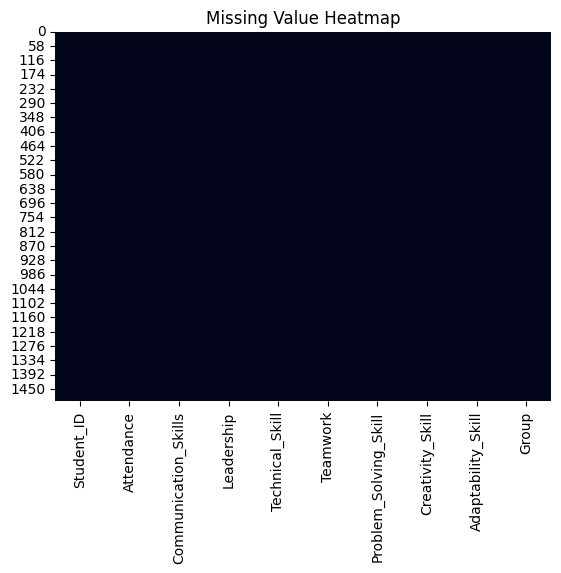

In [23]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()
#These commands create a heatmap to visualize missing values in the dataset, making it easy to see which columns have gaps.

In [24]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
df.describe()
#This command generates summary statistics for numerical columns in the dataset, showing metrics like mean, median, standard deviation, min, and max values.

,Attendance,Communication_Skills,Leadership,Technical_Skill,Teamwork,Problem_Solving_Skill,Creativity_Skill,Adaptability_Skill
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,75.242000,5.492667,5.410000,5.621333,5.497333,5.560667,5.481333,5.610667
std,14.723177,2.865790,2.883188,2.828064,2.893137,2.934177,2.957840,2.841209
min,50.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,63.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,75.000000,5.000000,5.000000,6.000000,6.000000,6.000000,6.000000,6.000000
75%,87.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


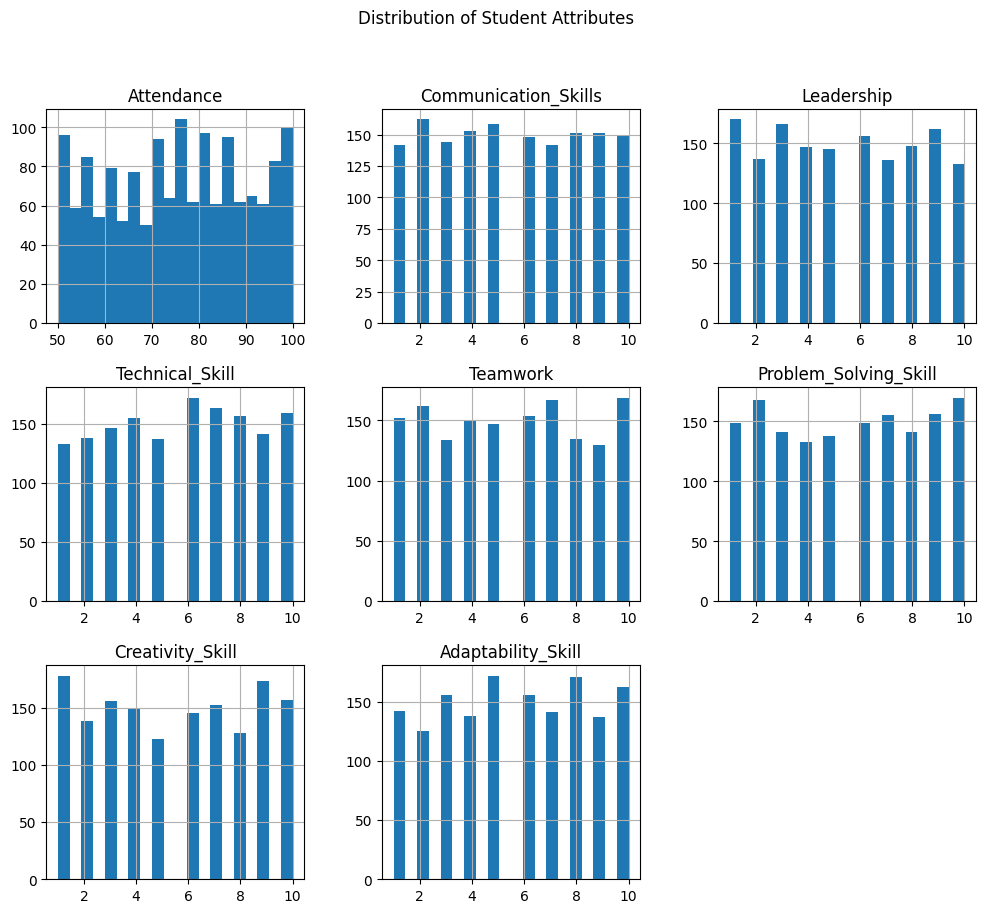

In [13]:
df.hist(figsize=(12, 10), bins=20)
plt.suptitle("Distribution of Student Attributes")
plt.show()
#Attendance:The values are much higher than other attributes (50–100 range).

#The spread is large, with some very high or low values that could be outliers.

#Other Skills (Communication, Leadership, Technical Skill, Teamwork, Problem Solving, Creativity, Adaptability):

#Most data are clustered at the lower end (1–10).

#Each skill shows a few potential outliers above the main cluster.

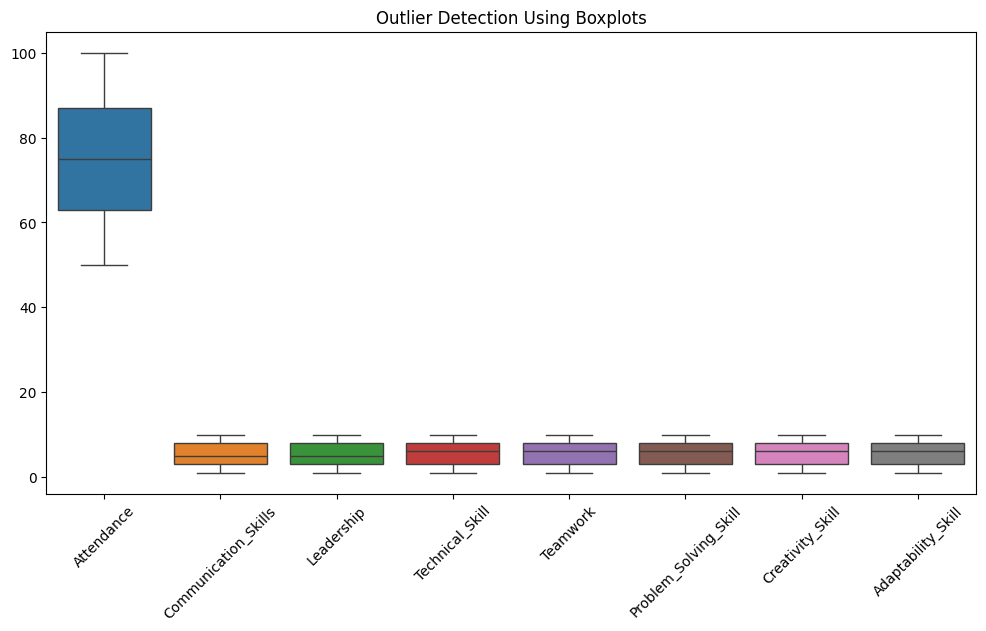

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=["Student_ID"]))
plt.xticks(rotation=45)
plt.title("Outlier Detection Using Boxplots")
plt.show()
#This boxplot diagram shows the distribution of each numeric variable and helps identify outliers.
#The box represents the interquartile range, the line inside is the median, whiskers show the normal data range, and points outside are outliers.
#It is used to compare variables and detect unusual values that may affect analysis.


In [15]:
from sklearn.preprocessing import StandardScaler

features = df.drop(columns=["Student_ID"])#Selects all numeric columns except the identifier, which shouldn’t be scaled.
scaler = StandardScaler()#Creates a StandardScaler object, which standardizes features by removing the mean and scaling to unit variance.
scaled_features = scaler.fit_transform(features)
#This makes attributes like Attendance (50–100) comparable to skills (1–10), which is important for machine learning algorithms that are sensitive to feature scale, like KNN or SVM.


In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["Group"] = kmeans.fit_predict(scaled_features)
#This code uses the K-Means algorithm to automatically group students into 3 distinct clusters based on their skill patterns and assigns each student a group label (0, 1, or 2) in a new column.


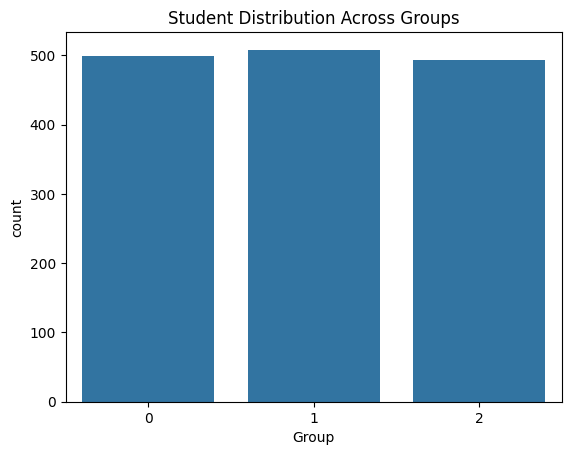

In [17]:
sns.countplot(x="Group", data=df)
plt.title("Student Distribution Across Groups")
plt.show()
#It helps visualize whether the clusters are balanced or uneven and shows how students are distributed after clustering.

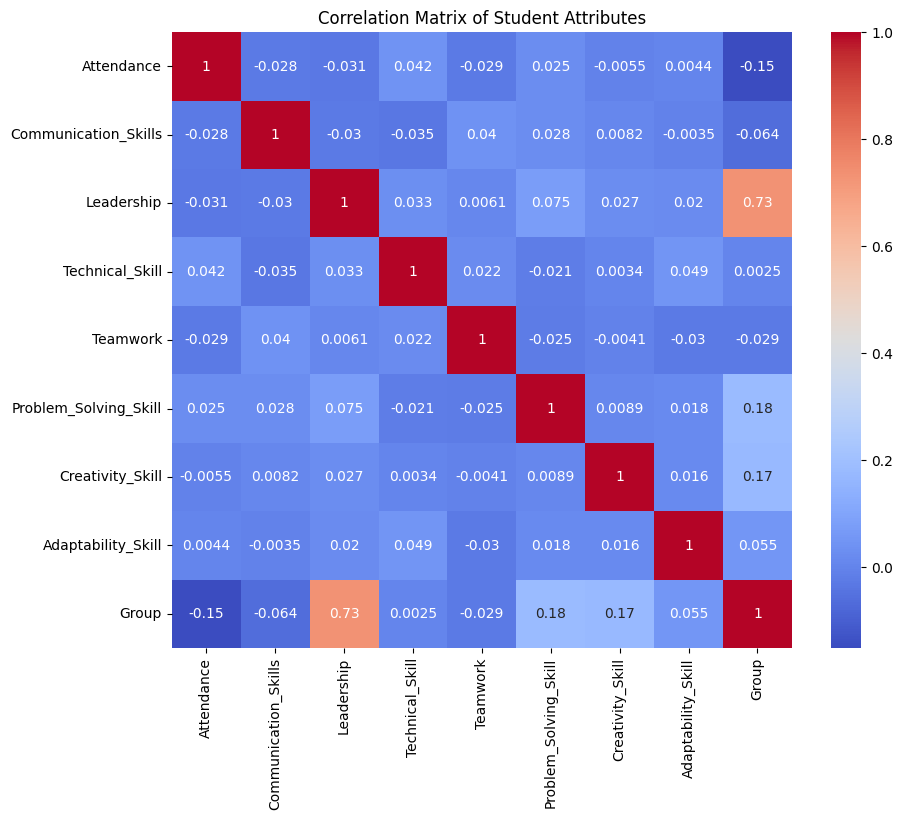

In [34]:
plt.figure(figsize=(10, 8))

numeric_df = df.drop(columns=["Student_ID"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix of Student Attributes")
plt.show()
#The purpose of this code is to visualize relationships between student attributes, showing how strongly they are related to each other. It helps identify positive, negative, or weak correlations, which is useful for understanding data patterns, feature selection, and analysis.

In [31]:
X = df.drop(columns=["Student_ID", "Group"])
y = df["Group"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#The purpose is to prepare the data for modeling by separating features and labels and scaling the features so they are on the same range


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
#The purpose of this code is to evaluate the model’s performance by training it on one portion of the data and testing it on unseen data to check how well it generalizes.

In [33]:
knn = KNeighborsClassifier(n_neighbors=5)#creates a K-Nearest Neighbors (KNN) classifier.
knn.fit(X_train, y_train)#means the algorithm will look at the 5 nearest neighbors of a data point to decide its class.


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [41]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
#This code calculates the overall Accuracy and prints a detailed Classification Report

Accuracy: 0.1
              precision    recall  f1-score   support

           1       0.09      0.15      0.11        27
           2       0.09      0.12      0.10        26
           3       0.13      0.16      0.14        31
           4       0.06      0.06      0.06        32
           5       0.21      0.17      0.19        40
           6       0.08      0.11      0.09        28
           7       0.05      0.05      0.05        22
           8       0.04      0.03      0.04        32
           9       0.06      0.03      0.04        31
          10       0.17      0.10      0.12        31

    accuracy                           0.10       300
   macro avg       0.10      0.10      0.09       300
weighted avg       0.10      0.10      0.10       300



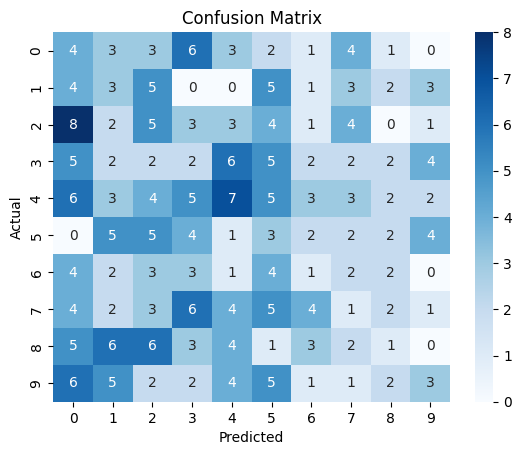

In [40]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


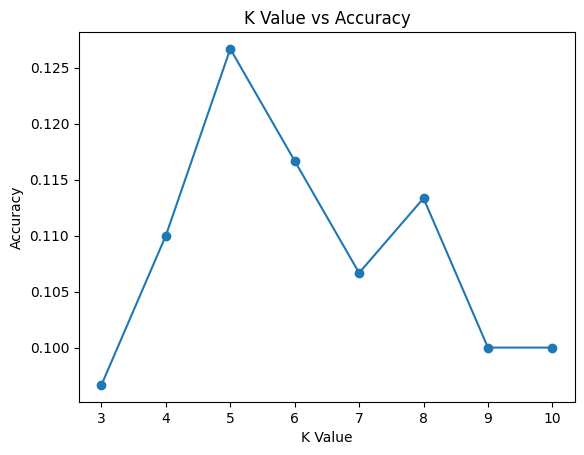

In [39]:
accuracy_list = []

for k in range(3, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy_list.append(accuracy_score(y_test, y_pred))

plt.plot(range(3, 11), accuracy_list, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K Value vs Accuracy")
plt.show()

#This code tests different values for kn the KNN algorithm and plots a line graph to help you visually identify which value provides the highest accuracy for your model.

In [36]:
# Separate features and target
# We use 'Adaptability_Skill' which exists in your dataset columns
X = df.drop(['Student_ID', 'Adaptability_Skill'], axis=1)
y = df['Adaptability_Skill']

# Split the data into training and testing sets (Requirement 3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features (Required for algorithms like KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [37]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)#Initializes the KNN algorithm.
knn.fit(X_train_scaled, y_train)#Trains model on data.
knn_pred = knn.predict(X_test_scaled)#Predicts groups for testing.

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)#Creates forest of trees.
rf.fit(X_train, y_train)#Learns patterns from data.
rf_pred = rf.predict(X_test)#Generates final group predictions.

--- KNN Performance ---
Accuracy: 0.18
              precision    recall  f1-score   support

           1       0.30      0.44      0.36        27
           2       0.26      0.27      0.26        26
           3       0.22      0.26      0.24        31
           4       0.08      0.06      0.07        32
           5       0.28      0.20      0.23        40
           6       0.11      0.14      0.12        28
           7       0.06      0.09      0.08        22
           8       0.18      0.19      0.18        32
           9       0.12      0.06      0.08        31
          10       0.12      0.10      0.11        31

    accuracy                           0.18       300
   macro avg       0.17      0.18      0.17       300
weighted avg       0.18      0.18      0.17       300



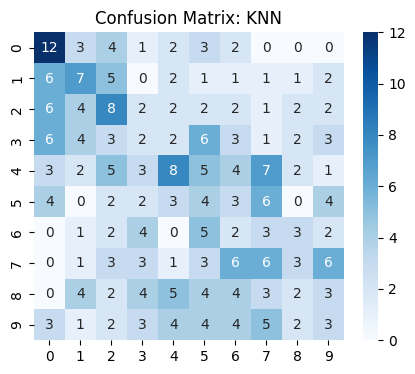

--- Random Forest Performance ---
Accuracy: 0.18
              precision    recall  f1-score   support

           1       0.36      0.48      0.41        27
           2       0.26      0.19      0.22        26
           3       0.14      0.10      0.12        31
           4       0.18      0.09      0.12        32
           5       0.23      0.12      0.16        40
           6       0.16      0.18      0.17        28
           7       0.14      0.23      0.17        22
           8       0.16      0.25      0.20        32
           9       0.17      0.16      0.17        31
          10       0.05      0.06      0.06        31

    accuracy                           0.18       300
   macro avg       0.19      0.19      0.18       300
weighted avg       0.18      0.18      0.18       300



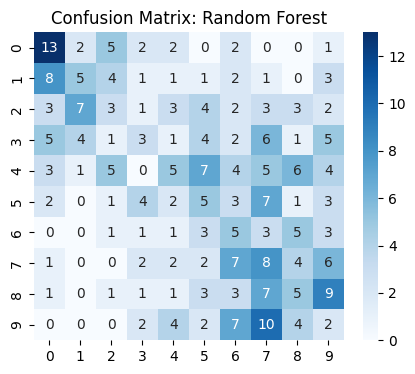

In [42]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate_model(name, y_test, y_pred):
    print(f"--- {name} Performance ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))
    
    # Plotting Confusion Matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

evaluate_model("KNN", y_test, knn_pred)
evaluate_model("Random Forest", y_test, rf_pred)
#This project uses Random Forest Machine Learning to automatically categorize students into Groups A, B, or C

In [43]:
# 1. Separate Features and Target
# We drop 'Student_ID' as it's just an index and not a predictive feature
X = df.drop(['Student_ID', 'Adaptability_Skill'], axis=1)
y = df['Adaptability_Skill']

# 2. Split the data into Training and Testing sets (Requirement 3)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling (Requirement 3)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_preds = knn.predict(X_test_scaled)

In [45]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

--- KNN Evaluation ---
Accuracy: 0.18
              precision    recall  f1-score   support

           1       0.30      0.44      0.36        27
           2       0.26      0.27      0.26        26
           3       0.22      0.26      0.24        31
           4       0.08      0.06      0.07        32
           5       0.28      0.20      0.23        40
           6       0.11      0.14      0.12        28
           7       0.06      0.09      0.08        22
           8       0.18      0.19      0.18        32
           9       0.12      0.06      0.08        31
          10       0.12      0.10      0.11        31

    accuracy                           0.18       300
   macro avg       0.17      0.18      0.17       300
weighted avg       0.18      0.18      0.17       300



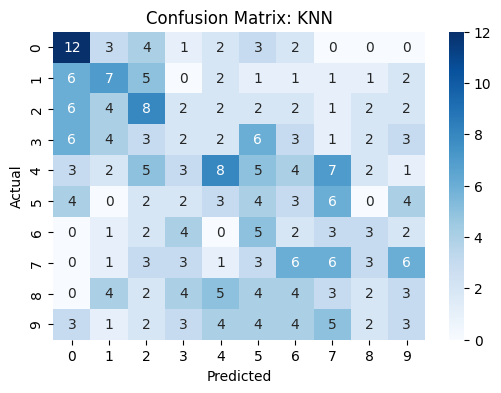

--- Random Forest Evaluation ---
Accuracy: 0.18
              precision    recall  f1-score   support

           1       0.36      0.48      0.41        27
           2       0.26      0.19      0.22        26
           3       0.14      0.10      0.12        31
           4       0.18      0.09      0.12        32
           5       0.23      0.12      0.16        40
           6       0.16      0.18      0.17        28
           7       0.14      0.23      0.17        22
           8       0.16      0.25      0.20        32
           9       0.17      0.16      0.17        31
          10       0.05      0.06      0.06        31

    accuracy                           0.18       300
   macro avg       0.19      0.19      0.18       300
weighted avg       0.18      0.18      0.18       300



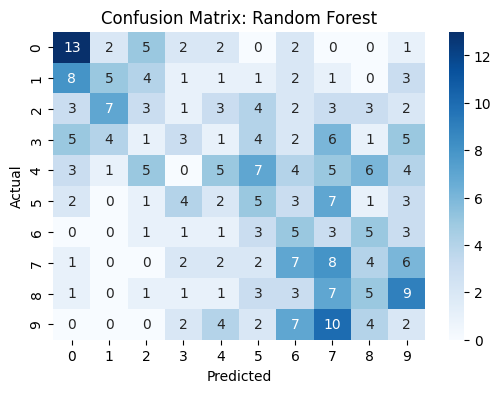

In [46]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate(name, y_true, y_pred):
    print(f"--- {name} Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.2f}")
    print(classification_report(y_true, y_pred))
    
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

evaluate("KNN", y_test, knn_preds)
evaluate("Random Forest", y_test, rf_preds)

In [47]:
import joblib

# Replace 'rf' with your best performing model variable
joblib.dump(rf, 'best_student_model.pkl')
joblib.dump(scaler, 'scaler.pkl') # Save the scaler too!
print("Model saved successfully!")

Model saved successfully!


In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. Load your data (ensure the filename matches your actual file)
df = pd.read_csv("student_grouping_dataset_1500.csv")

# 2. Calculate Overall Marks (0-100 Scale)
# We take the average of all skill columns (1-10) and the Attendance (0-100)
skills = ['Communication_Skills', 'Leadership', 'Technical_Skill', 
          'Teamwork', 'Problem_Solving_Skill', 'Creativity_Skill', 'Adaptability_Skill']

# Convert skills to 100 scale then average with Attendance
df['Total_Marks'] = ((df[skills].mean(axis=1) * 10) + df['Attendance']) / 2

# 3. Define the Groups as per your requirement
def assign_group(marks):
    if marks >= 80:
        return 'Group A'
    elif marks >= 40:
        return 'Group B'
    else:
        return 'Group C'

df['Group'] = df['Total_Marks'].apply(assign_group)

# 4. Prepare for Training
X = df.drop(['Student_ID', 'Total_Marks', 'Group'], axis=1)
y = df['Group']

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Train the new Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Save the NEW model and scaler
joblib.dump(model, 'student_group_model.pkl')
joblib.dump(scaler, 'group_scaler.pkl')

print("New Model Saved: student_group_model.pkl")
print("New Scaler Saved: group_scaler.pkl")

New Model Saved: student_group_model.pkl
New Scaler Saved: group_scaler.pkl
